Objective: Classification: Survived(Yes/No)
Success Criteria: Accuracy >80%
Constraints: Limited features, missingvalues, imbalanced classes

Dataset Shape: (891, 15)

First 5 Rows:
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

Data After Preprocessing:
   survive

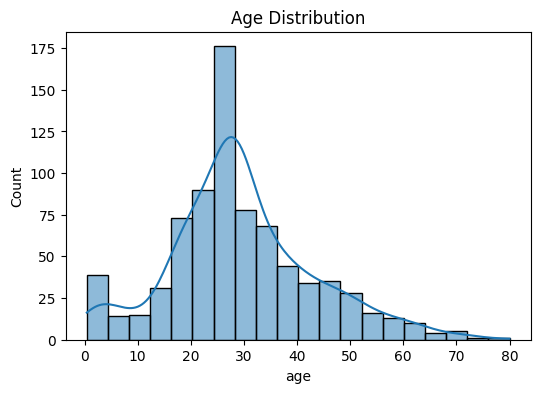

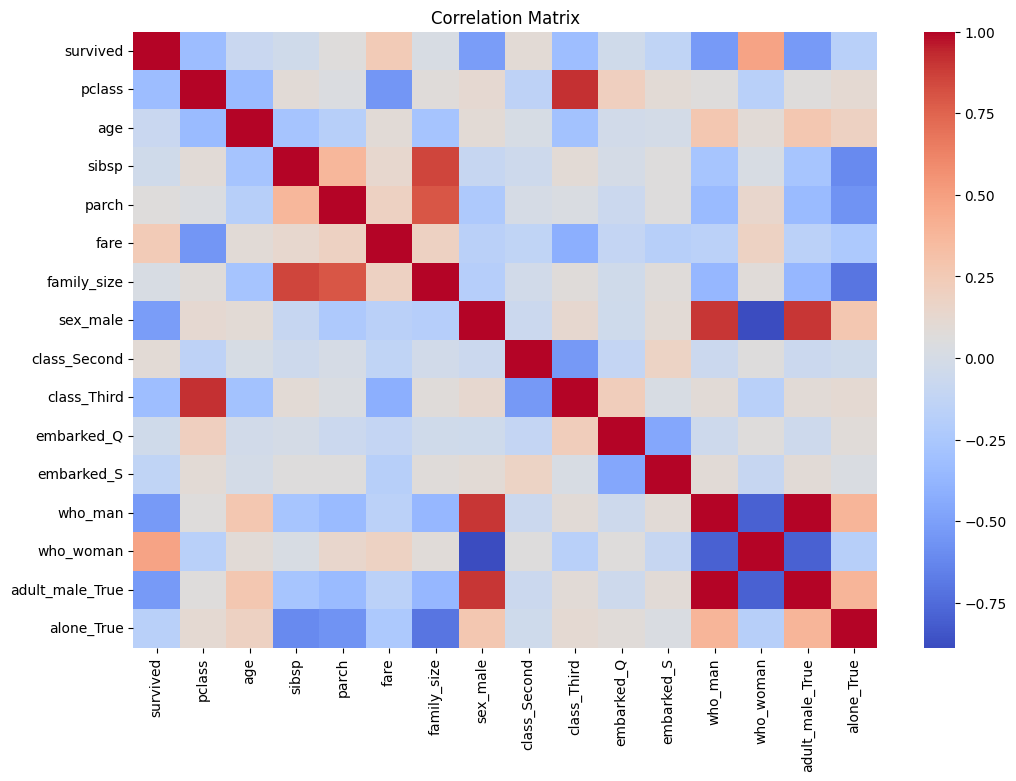


===== Model Evaluation =====
Accuracy : 0.8193548387096774
Precision: 0.7758620689655172
Recall   : 0.75

Confusion Matrix:
[[82 13]
 [15 45]]

First 10 Predictions:
[0 0 0 1 1 1 0 0 0 1]


In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

objective = "Classification: Survived(Yes/No)"
success_criteria = "Accuracy >80%"
constraints = "Limited features, missingvalues, imbalanced classes"

print("Objective:", objective)
print("Success Criteria:", success_criteria)
print("Constraints:", constraints)

df = sns.load_dataset("titanic")

print("\nDataset Shape:", df.shape)
print("\nFirst 5 Rows:")
print(df.head())

df['age'] = df['age'].fillna(df['age'].median())
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

df.drop(columns=['deck'], inplace=True)

df.drop_duplicates(inplace=True)

df['family_size'] = df['sibsp'] + df['parch']

df = pd.get_dummies(
    df,
    columns=['sex', 'class', 'embarked', 'who', 'adult_male', 'alone'],
    drop_first=True
)

print("\nData After Preprocessing:")
print(df.head())

plt.figure(figsize=(6, 4))
sns.histplot(df['age'], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

plt.figure(figsize=(12, 8))
corr = df.corr(numeric_only=True)
sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=False
)
plt.title("Correlation Matrix")
plt.show()

X = df.drop(columns=['survived'])
y = df['survived']

X = X.select_dtypes(include=['int64', 'float64', 'bool'])

X = X.astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)


y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("\n===== Model Evaluation =====")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)

print("\nConfusion Matrix:")
print(cm)

print("\nFirst 10 Predictions:")
print(y_pred[:10])

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)


In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)
